# SHAP Analysis v2 (Phase 4)

Feature importance via SHAP for the XGBoost yield model on monthly data.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

if Path.cwd().name == 'notebooks':
    os.chdir('..')

from src.models.yield_model import (
    build_yield_dataset_monthly, prepare_Xy
)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

## Load Monthly Data and Train XGBoost

In [2]:
DAILY_CSV = 'data/raw/climate_daily_2015_2024.csv'
YIELD_CSV = 'data/raw/nhb_yield_mock_2015_2024.csv'

df = build_yield_dataset_monthly(DAILY_CSV, YIELD_CSV)
X, y, feature_cols = prepare_Xy(df)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
model.fit(X_scaled, y, verbose=False)
model.save_model('models/xgb_yield_best.json')

## SHAP Waterfall Plot

Saved shap_waterfall.png


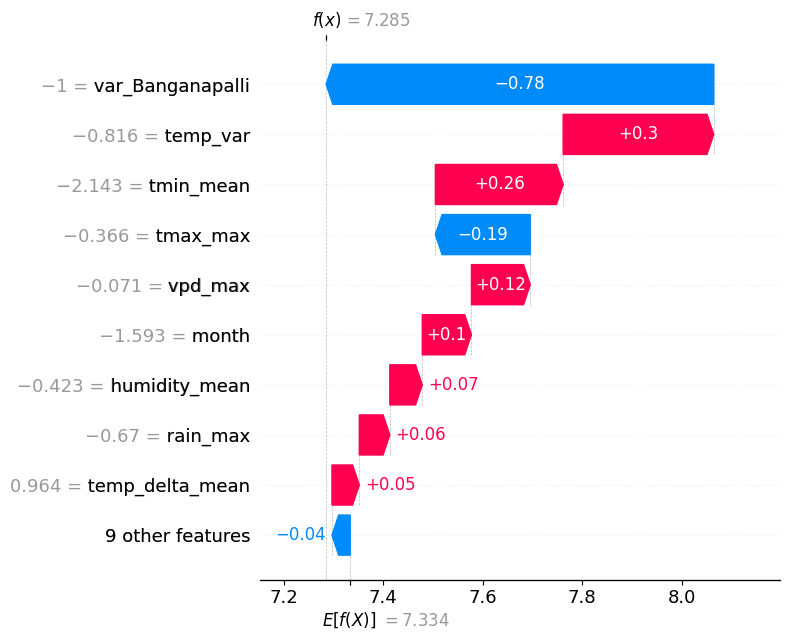

In [3]:
explainer = shap.Explainer(model, feature_names=feature_cols)
shap_values = explainer(X_scaled)

plt.figure()
shap.plots.waterfall(shap_values[0], show=False)
plt.tight_layout()
plt.savefig('reports/figures/shap_waterfall.png', dpi=150, bbox_inches='tight')
print("Saved shap_waterfall.png")

## SHAP Beeswarm Plot

In [4]:
plt.figure()
shap.plots.beeswarm(shap_values, show=False)
plt.tight_layout()
plt.savefig('reports/figures/shap_beeswarm.png', dpi=150, bbox_inches='tight')
print("Saved shap_beeswarm.png")

Saved shap_beeswarm.png


## Feature Importance Ranking

In [5]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("Feature Importance (SHAP):")
print(importance.to_string(index=False))

Feature Importance (SHAP):
         feature  mean_abs_shap
var_Banganapalli       0.720057
        vpd_mean       0.117583
        temp_var       0.109028
        tmax_max       0.107670
         vpd_max       0.101766
disease_severity       0.082875
       tmin_mean       0.077727
   humidity_mean       0.075648
        tmin_min       0.072582
       rain_days       0.066713
    humidity_min       0.064350
        rain_max       0.058468
 temp_delta_mean       0.056143
           month       0.055761
       tmax_mean       0.053339
       rain_mean       0.050030
      rain_cumul       0.011107
     var_Raspuri       0.000000


## Key Finding

Does `disease_severity` appear in the top features?
If yes → confirms the **novel contribution** of coupling disease detection with yield prediction.